# ASTR 499 Initial Photometry Practice
Written by Kiyoaki Okudaira<br>
*University of Washington / Kyushu University / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
The main purpose of this code is fundamentally understand photometry and what satmetrics and RECA project did. Therefore, this code preliminary process FITS file with satellite streaks and do satellite photometry with simple & fundamental methods.<br>
<br>
**History**<br>
coding 2025-10-12 : 1st coding<br>
update 2025-10-16 : Image mask

### Import and initial settings

In [64]:
# Public libraries
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import itertools

# Satmetrics
from satmetrics_main import image_rotation as imgrt

### Read and view original FITS file
In the future FITS data should be automatically downloaded by noirlab API

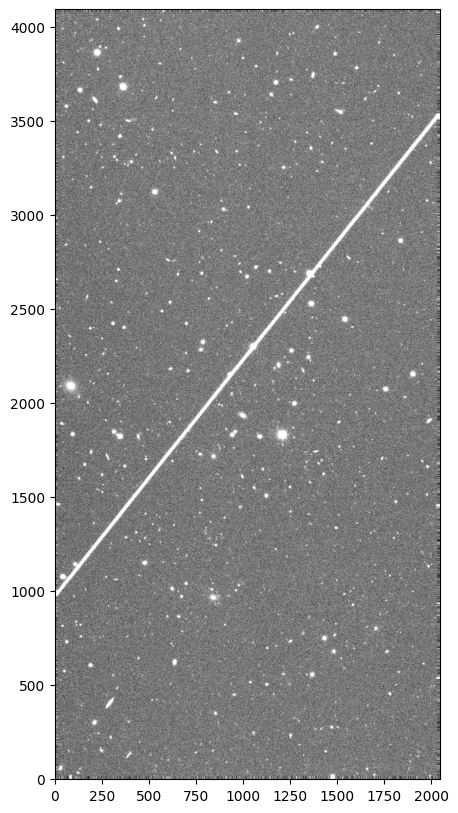

In [65]:
fits_filepath = "1103448.fits"

hdu = fits.open(fits_filepath)[0]
original_data = hdu.data
original_header = hdu.header

plt.figure(figsize=(10, 10))
plt.imshow(original_data, cmap='gray', origin='lower', vmin=np.percentile(original_data, 5), vmax=np.percentile(original_data, 95))

### Image rotation
There is a satellite streak!!! To make photometry easier, rotate image and get the steak to be horizontal<br>
At the first step, coordinates of the streak determined manually<br>
In the future this process should be done automatically with hough transform

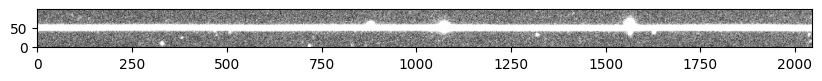

In [66]:
coord1 = [52,1038]   # detremined manually...
coord2 = [1995,3478] # detremined manually...
rt_angle = imgrt.determine_rotation_angle(coord1,coord2)
rotated_data = imgrt.rotate_image(original_data, rt_angle, [coord1,coord2])

plt.figure(figsize=(10, 10))
plt.imshow(rotated_data, cmap='gray', origin='lower', vmin=np.percentile(original_data, 5), vmax=np.percentile(original_data, 95))

### Streak photometry 1st try!
Preliminary image processing is done. Now, let's do satellite photometry!<br>
1st step : Count values along x axis

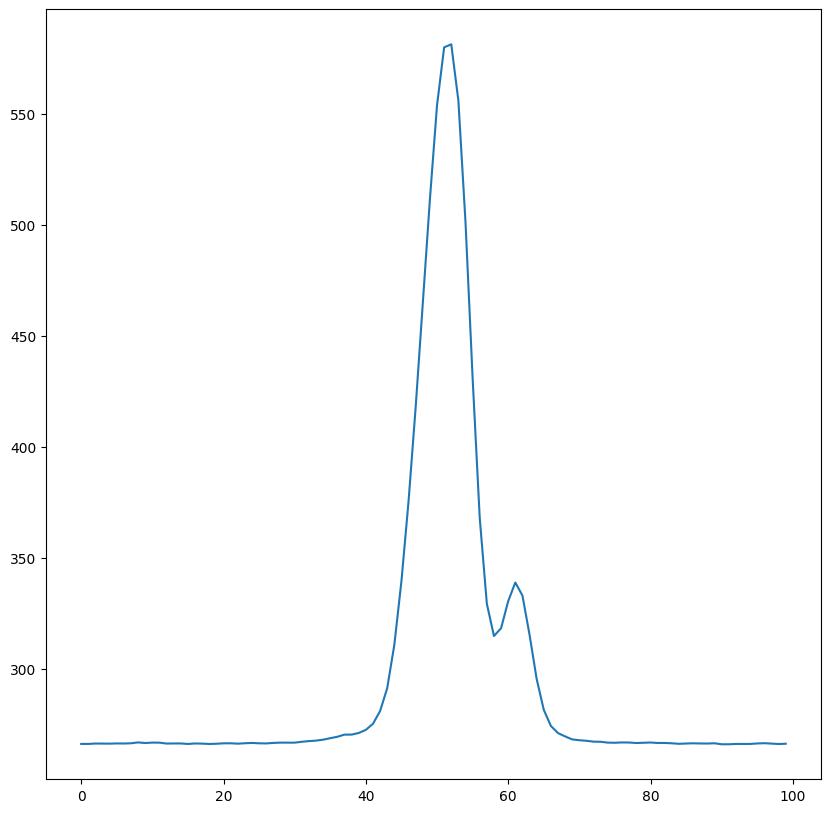

In [67]:
count_1d = np.ma.mean(rotated_data,axis=1)
y_1d = np.arange(len(count_1d))

plt.figure(figsize=(10, 10))
plt.plot(y_1d, count_1d)

The graph does not show "pure" Gaussian distribution due to other objects (like stars) and backgrounds.<br>
So, I have to remove them, even if this code is for prelinimary processing...

### Image mask
Remove bright objects like stars.

/opt/homebrew/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


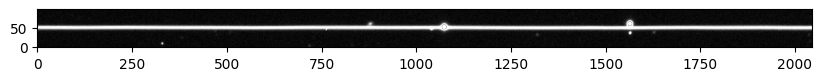

In [68]:
threshold = np.mean(rotated_data) + 3*np.std(rotated_data)
masked_data = np.ma.array(rotated_data,mask=(threshold<rotated_data))

plt.figure(figsize=(10, 10))
plt.imshow(masked_data, cmap='gray', origin='lower', vmin=np.percentile(masked_data, 5), vmax=np.percentile(masked_data, 95))

### Streak photometry 2nd try!
Now, I have a masked image. Retry photometry!

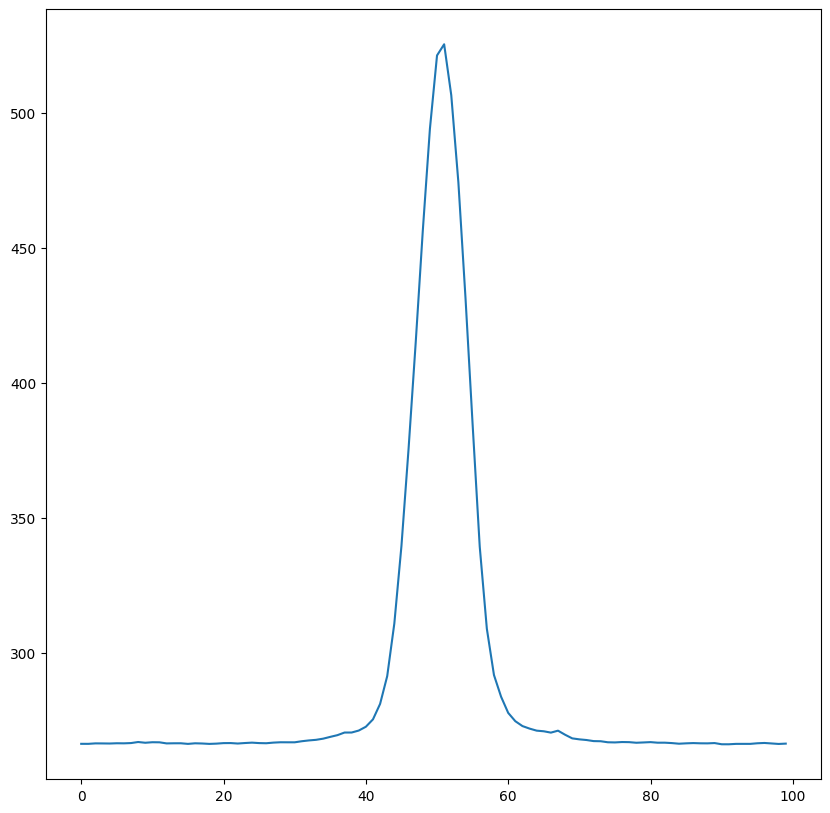

In [69]:
count_1d = np.ma.mean(masked_data,axis=1)
y_1d = np.arange(len(count_1d))

plt.figure(figsize=(10, 10))
plt.plot(y_1d, count_1d)

Seems to be good!<br>
Next, let's distinguish the streak from others by using Gaussian fitting.

[257.69758167  50.63395387   3.46901726 267.39677488]


/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


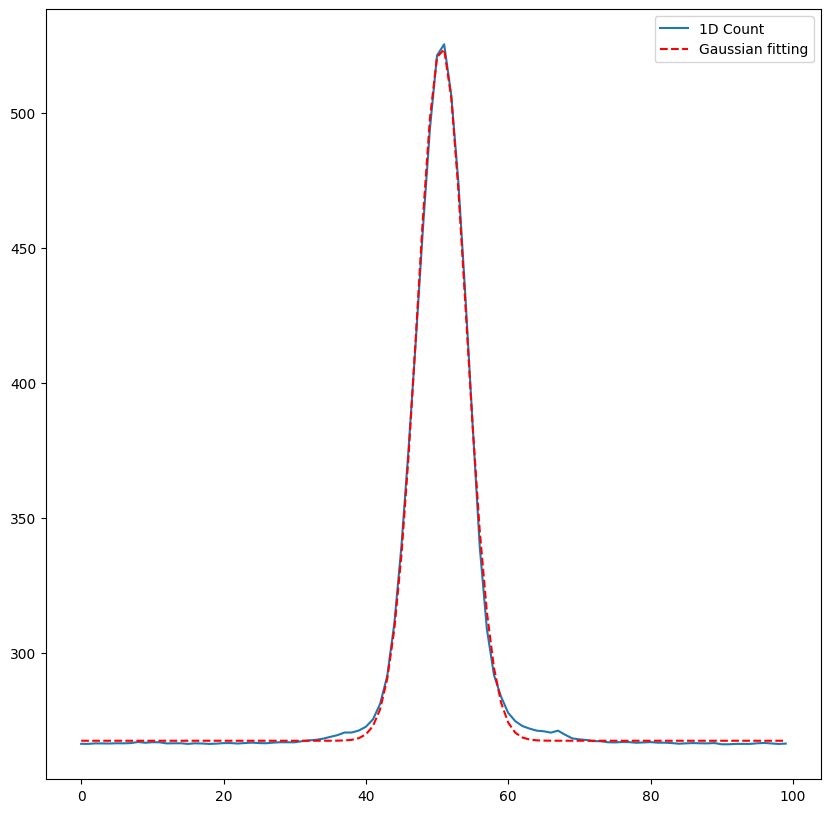

In [ ]:
# define gaussian destribution function
def func(x, a, mu, sigma, b):
    return a*np.exp(-(x-mu)**2/(2*sigma**2)) + b

param_ini = [count_1d.max(),np.mean(y_1d),1,np.median(count_1d)]
popt, pcov = curve_fit(func, y_1d, count_1d, p0=param_ini)
print(popt)
fitting = func(y_1d,popt[0],popt[1],popt[2],popt[3])

plt.figure(figsize=(10, 10))
plt.plot(y_1d,count_1d,label="1D Count")
plt.plot(y_1d,fitting,label="Gaussian fitting",color='red',linestyle='--')
plt.legend()

Fitting also seems to work well! Now, let's determine region.

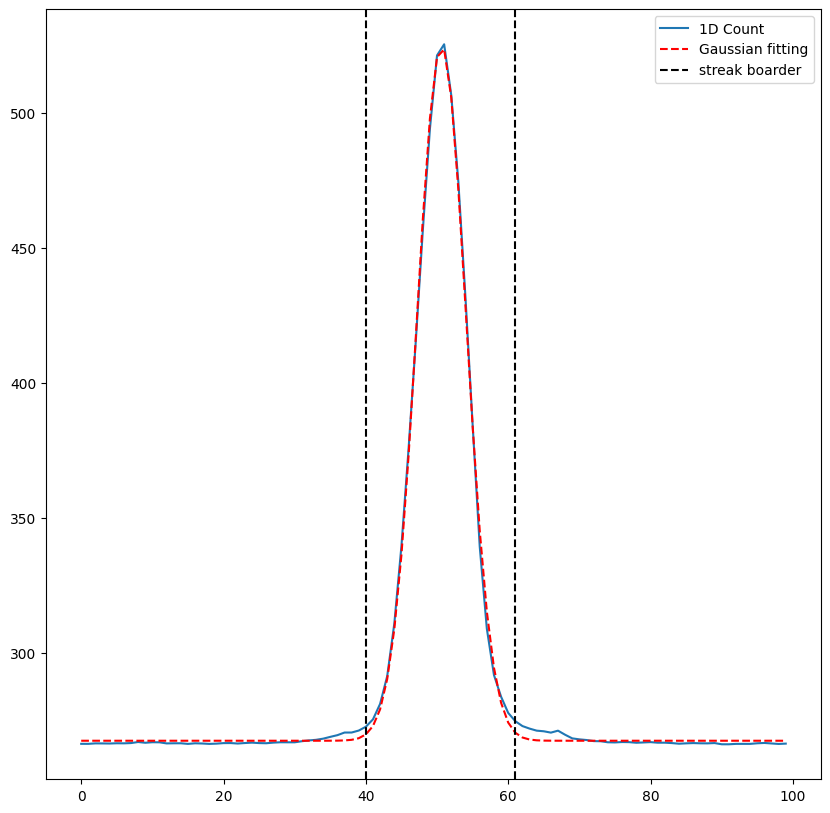

In [71]:
streak_y_min = int(popt[1] - 3 * popt[2])
streak_y_max = int(popt[1] + 3 * popt[2])

plt.figure(figsize=(10, 10))
plt.plot(y_1d,count_1d,label="1D Count")
plt.plot(y_1d,fitting,label="Gaussian fitting",color='red',linestyle='--')
plt.axvline(streak_y_min, color='black', linestyle='--', label='streak boarder')
plt.axvline(streak_y_max, color='black', linestyle='--')
plt.legend()

Final step : Photometry!<br>
But, there seems to be no zeropoint information in the FITS header...

In [76]:
streak_region_data = np.array([masked_data[i] for i in range(streak_y_min,streak_y_max+1)])
off_region_data = np.array([masked_data[i] for i in itertools.chain(range(0,streak_y_min),range(streak_y_max+1,len(masked_data)))])

sum_off_region = np.sum(off_region_data)
pixel_off_region = len(off_region_data)*len(off_region_data[0])
pixcount_off_region = sum_off_region/pixel_off_region

pixel_streak_region = len(streak_region_data)*len(streak_region_data[0])
sum_streak_region = np.sum(streak_region_data) - pixcount_off_region*pixel_streak_region
pixcount_streak_region = sum_streak_region / pixel_streak_region

arc_per_pix = 0.27
arccount_streak_region = pixcount_streak_region / (arc_per_pix**2)


print("Streak brightness : {0} [count/(pix^2)]".format(pixcount_streak_region))
print("Streak brightness : {0} [count/(arcsec^2)]".format(arccount_streak_region))

# zeropoint
# sb_mag_arcsec2 = -2.5*np.log10(arccount_streak_region) + zeropoint

Streak brightness : 128.34166628726945 [count/(pix^2)]
Streak brightness : 1760.5166843246836 [count/(arcsec^2)]


INITIAL SATELLITE PHOTOMETRY IS COMPLETED!!!